This is the initial simulation, \vers{I} is assumed to be in the x-y plane for dim=2 and x-z for dim=3.
In this plane [0,-1,0] is the psi=0 direction.

In [5]:
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
# import numba as nb

In [6]:
import matplotlib as mpl

mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble'] = r'\usepackage{bm}'

parent_dir = Path.cwd().parent
plt.style.use(parent_dir / "softmatter.mplstyle")


In [7]:
# System parameters

dim = 3

D_n = 0.067 # realistic value
D_r = 0.
V0 = 1.
w0 = 0. # realistic value = 1, w0 = 0 for benchmark

vec_I = np.zeros(dim)
vec_I[-1] = -1

In [8]:
# Simulation parameters

N_samples = 10**3
nt = 1000    # number of times steps

dt = 5*10**-2
if not dt < 0.01 / D_n:
    raise Exception("too large time step")

In [9]:
r0 = np.zeros((dim, N_samples))

n0 = np.zeros((dim,N_samples))
n0[0,:] = 1 # n0[-1,:] = 1

r = np.copy(r0) # initial position
n = np.copy(n0) # initial orientation

In [10]:
# Tensor for saving positions
r_history = np.zeros((nt+1, dim, N_samples))
r_history[0,:,:] = r0

n_history = np.zeros((nt+1, dim, N_samples))
n_history[0,:,:] = n0

In [11]:
zeta_n = np.random.normal(loc=0,scale=1,size = (nt, dim, N_samples))
zeta_r = np.random.normal(loc=0,scale=1,size = (nt, dim, N_samples))

dn_rand = np.sqrt(2*D_n*dt)*zeta_n
dr_rand = np.sqrt(2*D_r*dt)*zeta_r

In [12]:
# Time evolution

for it in range(nt):
    
    dn = dn_rand[it,:,:] # noise term
    dn -= n*np.sum(n*dn, axis=0) # project onto tangent space

    n += dn
    n /= np.linalg.norm(n, axis=0)
    
    r = n*V0*dt + r + dr_rand[it,:]
    r_history[it+1,:,:] = r
    n_history[it+1,:,:] = n

C:\Users\Dell\AppData\Local\Temp\ipykernel_17376\1933811443.py:19: RuntimeWarning: invalid value encountered in log
  plt.plot(t_steps,np.log(correlator))


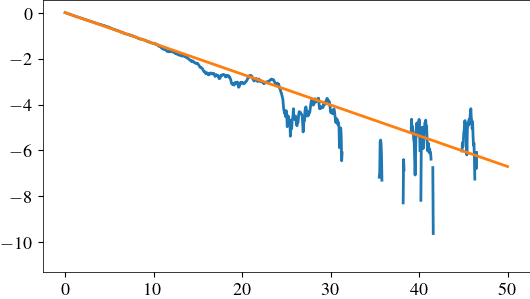

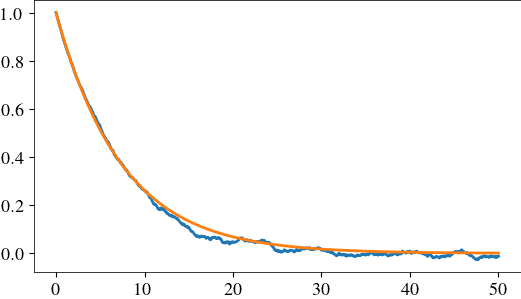

In [13]:
# Computing correlator 1

def correlator_benchmark1(dim, t):
    if dim == 2:
        return np.exp(-D_n*t)#2*(1-np.exp(-2*D_n*t))
    elif dim == 3: 
        return np.exp(-2*D_n*t)

product_n = n_history*n0[None,:]
sums_n = np.sum(product_n,axis=1)   # (nt, N_samples)

std_correlator = 1/np.sqrt(N_samples) * np.std(sums_n, axis=1, ddof=1)


correlator = np.mean(sums_n, axis=1)

t_steps = dt*np.arange(0,nt+1)

plt.plot(t_steps,np.log(correlator))
plt.plot(t_steps,np.log(correlator_benchmark1(dim, t_steps)))
plt.show()


plt.plot(t_steps,correlator)
plt.plot(t_steps,correlator_benchmark1(dim, t_steps))
plt.show()

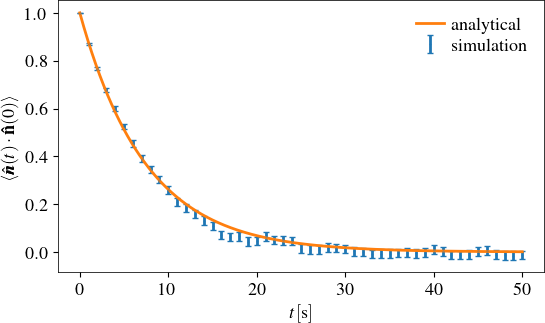

In [14]:
# Computing correlator 1

def correlator_benchmark1(dim, t):
    if dim == 2:
        return np.exp(-D_n*t)#2*(1-np.exp(-2*D_n*t))
    elif dim == 3: 
        return np.exp(-2*D_n*t)

product_n = n_history*n0[None,:]
sums_n = np.sum(product_n,axis=1)   # (nt, N_samples)




correlator = np.mean(sums_n, axis=1)
std_correlator = 1/np.sqrt(N_samples) * np.std(sums_n, axis=1, ddof=1)
t_steps = dt*np.arange(0,nt+1)


plot_every = 20
idx = np.arange(0, len(t_steps), plot_every)


plt.errorbar(
    t_steps[idx],
    correlator[idx],
    yerr=std_correlator[idx],
    fmt='.',
    markersize=0.5,
    capsize=2,
    label='simulation'
)
plt.plot(t_steps,correlator_benchmark1(dim, t_steps), label="analytical")
plt.xlabel(r'$t[\textrm{s}]$')
plt.ylabel(r'$\langle \bm{\hat{n}}(t)\cdot \mathbf{\hat{n}}(0)\rangle$')
plt.legend()
plt.show()






In [15]:
v

NameError: name 'v' is not defined

In [ ]:
# Combined plots

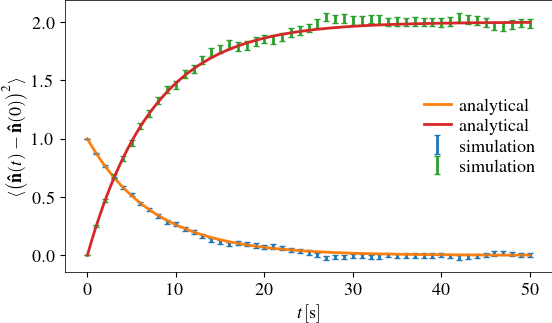

In [ ]:



# Computing correlator 1

def correlator_benchmark1(dim, t):
    if dim == 2:
        return np.exp(-D_n*t)#2*(1-np.exp(-2*D_n*t))
    elif dim == 3: 
        return np.exp(-2*D_n*t)

product_n = n_history*n0[None,:]
sums_n = np.sum(product_n,axis=1)   # (nt, N_samples)




correlator = np.mean(sums_n, axis=1)
std_correlator = 1/np.sqrt(N_samples) * np.std(sums_n, axis=1, ddof=1)
t_steps = dt*np.arange(0,nt+1)


plot_every = 20
idx = np.arange(0, len(t_steps), plot_every)


plt.errorbar(
    t_steps[idx],
    correlator[idx],
    yerr=std_correlator[idx],
    fmt='.',
    markersize=0.5,
    capsize=2,
    label='simulation'
)
plt.plot(t_steps,correlator_benchmark1(dim, t_steps), label="analytical")
plt.xlabel(r'$t[\textrm{s}]$')
plt.ylabel(r'$\langle \mathbf{\hat{n}}(t)\cdot \mathbf{\hat{n}}(0)\rangle$')
plt.legend()





# Computing correlator 2

def correlator_benchmark2(dim, t):
    if dim == 2:
        return 2*(1-np.exp(-D_n*t))
    elif dim == 3: 
        return 2*(1-np.exp(-2*D_n*t))

Delta_n = n_history-n0[None,:]
sums_n = np.sum(Delta_n**2,axis=1)
correlator2 = np.mean(sums_n, axis=1)
std_correlator2 = 1/np.sqrt(N_samples) * np.std(sums_n, axis=1, ddof=1)

t_steps = dt*np.arange(0,nt+1)


plt.errorbar(
    t_steps[idx],
    correlator2[idx],
    yerr=std_correlator2[idx],
    fmt='.',
    markersize=0.5,
    capsize=2,
    label='simulation'
)
plt.plot(t_steps,correlator_benchmark2(dim, t_steps), label="analytical")
plt.xlabel(r'$t[\textrm{s}]$')
plt.ylabel(r'$\Bigl \mathbf{\hat{n}}(t)\cdot \mathbf{\hat{n}}(0)\Biggr$')
plt.ylabel(r'$\langle \bigl(\mathbf{\hat n}(t)-\mathbf{\hat n}(0)\bigr)^2\rangle$')
plt.legend()
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_17376\420950930.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


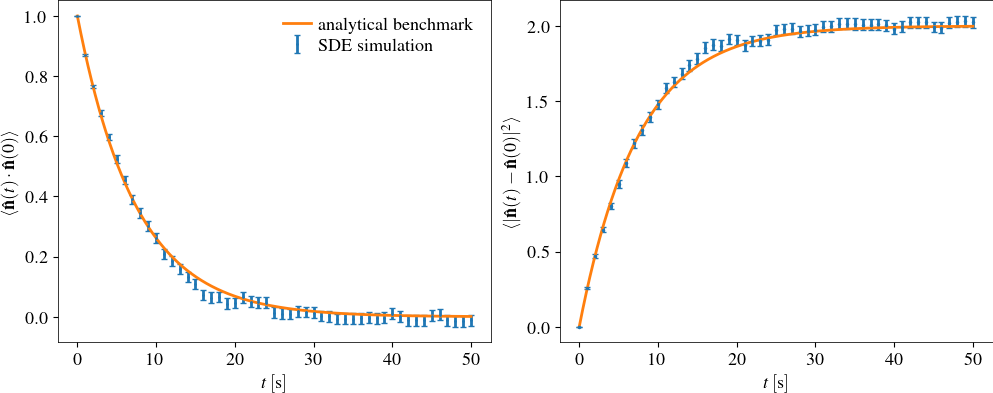

In [18]:
# Computing correlator 1

def correlator_benchmark1(dim, t):
    if dim == 2:
        return np.exp(-D_n*t)
    elif dim == 3: 
        return np.exp(-2*D_n*t)

product_n = n_history * n0[None, :]
sums_n = np.sum(product_n, axis=1)   # shape: (nt+1, N_samples)

correlator = np.mean(sums_n, axis=1)
std_correlator = np.std(sums_n, axis=1, ddof=1) / np.sqrt(N_samples)

t_steps = dt * np.arange(0, nt+1)


# Computing correlator 2

def correlator_benchmark2(dim, t):
    if dim == 2:
        return 2 * (1 - np.exp(-D_n*t))
    elif dim == 3: 
        return 2 * (1 - np.exp(-2*D_n*t))

Delta_n = n_history - n0[None, :]
sums_n2 = np.sum(Delta_n**2, axis=1)

correlator2 = np.mean(sums_n2, axis=1)
std_correlator2 = np.std(sums_n2, axis=1, ddof=1) / np.sqrt(N_samples)


# Plotting

plot_every = 20
idx = np.arange(0, len(t_steps), plot_every)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# --- subplot 1: orientation autocorrelation ---

axs[0].errorbar(
    t_steps[idx],
    correlator[idx],
    yerr=std_correlator[idx],
    fmt='.',
    markersize=2,
    capsize=2,
    label='SDE simulation'
)

axs[0].plot(
    t_steps,
    correlator_benchmark1(dim, t_steps),
    label='analytical benchmark'
)

axs[0].set_xlabel(r'$t\, [\mathrm{s}]$')
axs[0].set_ylabel(
    r'$\langle \hat{\mathbf{n}}(t)\cdot\hat{\mathbf{n}}(0)\rangle$'
)
axs[0].legend()


# --- subplot 2: orientational mean-square displacement ---

axs[1].errorbar(
    t_steps[idx],
    correlator2[idx],
    yerr=std_correlator2[idx],
    fmt='.',
    markersize=3,
    capsize=2,
    # label='SDE simulation'
)

axs[1].plot(
    t_steps,
    correlator_benchmark2(dim, t_steps),
    # label='analytical benchmark'
)

axs[1].set_xlabel(r'$t\, [\mathrm{s}]$')
axs[1].set_ylabel(
    r'$\langle |\hat{\mathbf{n}}(t)-\hat{\mathbf{n}}(0)|^2\rangle$'
)
axs[1].legend()


# Save as vector graphics for Overleaf
fig.savefig("orientation_correlators.pdf", bbox_inches="tight")
# fig.savefig("orientation_correlators.svg", bbox_inches="tight")  # optional

plt.show()

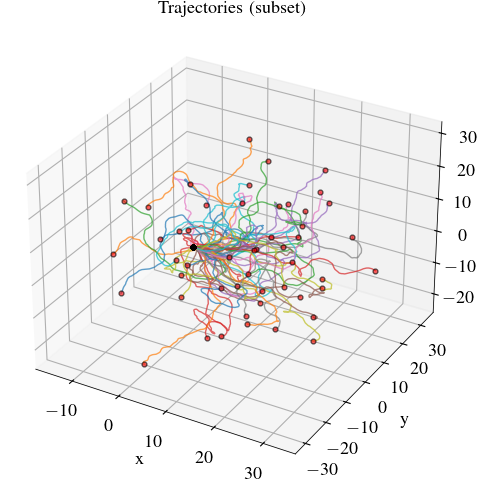

In [ ]:
# Visualize trajectories in r_history
# r_history shape: (nt+1, dim, N_samples)

n_show = min(50, N_samples)           # number of trajectories to plot
idx = np.linspace(0, N_samples - 1, n_show, dtype=int)

t = np.arange(r_history.shape[0])

if dim == 2:
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in idx:
        ax.plot(r_history[:, 0, i], r_history[:, 1, i], lw=1, alpha=0.7)
        ax.scatter(r_history[0, 0, i], r_history[0, 1, i], s=10, c="k", alpha=0.6)
        ax.scatter(r_history[-1, 0, i], r_history[-1, 1, i], s=12, c="r", alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Trajectories (subset)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)
    plt.show()

elif dim == 3:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    for i in idx:
        ax.plot(r_history[:, 0, i], r_history[:, 1, i], r_history[:, 2, i], lw=1, alpha=0.7)
        ax.scatter(r_history[0, 0, i], r_history[0, 1, i], r_history[0, 2, i], s=10, c="k", alpha=0.6)
        ax.scatter(r_history[-1, 0, i], r_history[-1, 1, i], r_history[-1, 2, i], s=12, c="r", alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Trajectories (subset)")
    plt.show()

In [ ]:
y_final = r_history[-1,0,:]
if_positive = y_final>0
if_negative = y_final<0
n_positive = np.sum(if_positive)
n_negative = np.sum(if_negative)
print(n_negative, n_positive)

308 692


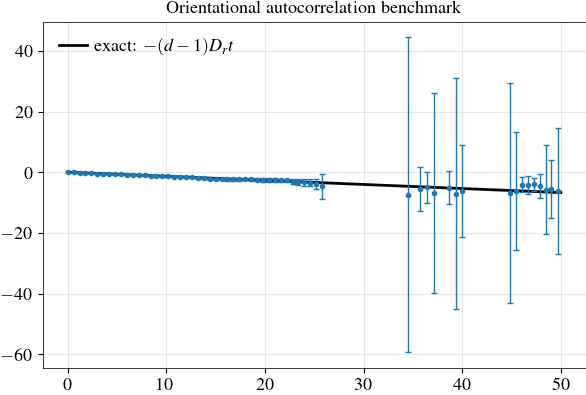

Reliable points: 713 / 1001
RMS log-error: 8.789e-01
Max |log-error|: 6.154e+00
Max |log-error| / SEM_log: 2.52


In [ ]:
# Computing correlator 1 with error bars on log(<n(t).n(0)>)

def log_correlator_benchmark(dim, D_n, t):
    return -(dim - 1) * D_n * t

t_steps = dt * np.arange(nt + 1)

# Dot product n(t).n(0), shape: (time, samples)
dots = np.sum(n_history * n0[None, :, :], axis=1)

# Estimate uncertainty by blocking samples
n_blocks = 20
block_size = N_samples // n_blocks
N_used = n_blocks * block_size

dots_used = dots[:, :N_used]
dots_blocks = dots_used.reshape(nt + 1, n_blocks, block_size)

# Block estimates of C(t) = <n(t).n(0)>
C_blocks = np.mean(dots_blocks, axis=2)

C_mean = np.mean(C_blocks, axis=1)
C_sem = np.std(C_blocks, axis=1, ddof=1) / np.sqrt(n_blocks)

# Log-transform the mean correlator
# Error propagation: sigma_logC ≈ sigma_C / C
log_C = np.full_like(C_mean, np.nan)
log_C_sem = np.full_like(C_mean, np.nan)

valid = C_mean > 0
log_C[valid] = np.log(C_mean[valid])
log_C_sem[valid] = C_sem[valid] / C_mean[valid]

log_C_exact = log_correlator_benchmark(dim, D_n, t_steps)

# Do not plot every error bar, otherwise the figure is unreadable
plot_every = max(1, len(t_steps) // 80)
idx = np.where(valid)[0][::plot_every]

plt.figure(figsize=(7, 4.5))

plt.plot(
    t_steps,
    log_C_exact,
    "k-",
    linewidth=2,
    label=r"exact: $-(d-1)D_r t$",
)

plt.errorbar(
    t_steps[idx],
    log_C[idx],
    yerr=1.96 * log_C_sem[idx],
    fmt="o",
    markersize=3,
    capsize=2,
    linewidth=1,
    # label=r"simulation: $\log\langle \mathbf n(t)\cdot\mathbf n(0)\rangle$",
)

# plt.xlabel(r"$t$")
# plt.ylabel(r"$\log\langle \mathbf n(t)\cdot\mathbf n(0)\rangle$")
plt.title("Orientational autocorrelation benchmark")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Error diagnostics in the log-correlator itself
log_error = log_C - log_C_exact

reliable = valid & np.isfinite(log_C_sem) & (log_C_sem > 0)

print(f"Reliable points: {np.sum(reliable)} / {len(t_steps)}")
print(f"RMS log-error: {np.sqrt(np.mean(log_error[reliable]**2)):.3e}")
print(f"Max |log-error|: {np.max(np.abs(log_error[reliable])):.3e}")
print(f"Max |log-error| / SEM_log: {np.max(np.abs(log_error[reliable] / log_C_sem[reliable])):.2f}")

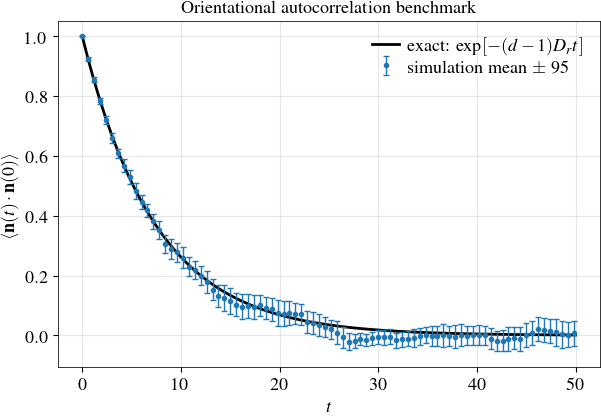

RMS weak error: 1.603e-02
Max absolute weak error: 5.390e-02
Max |weak error| / SEM: 4.05


In [ ]:
# Computing correlator 1 with error bars, no log transform

def correlator_benchmark1(dim, t):
    return np.exp(-(dim - 1) * D_n * t)

t_steps = dt * np.arange(nt + 1)

# Dot product n(t) . n(0), shape: (nt+1, N_samples)
product_n = n_history * n0[None, :, :]
dots = np.sum(product_n, axis=1)

# Mean correlator
correlator = np.mean(dots, axis=1)

# Estimate Monte Carlo uncertainty by blocking the samples
n_blocks = 20
block_size = N_samples // n_blocks
N_used = n_blocks * block_size

dots_blocks = dots[:, :N_used].reshape(nt + 1, n_blocks, block_size)
correlator_blocks = np.mean(dots_blocks, axis=2)

correlator_mean = np.mean(correlator_blocks, axis=1)
correlator_sem = np.std(correlator_blocks, axis=1, ddof=1) / np.sqrt(n_blocks)

correlator_exact = correlator_benchmark1(dim, t_steps)

# Plot fewer error bars to avoid visual clutter
plot_every = max(1, (nt + 1) // 80)
idx = np.arange(0, nt + 1, plot_every)

plt.figure(figsize=(7, 4.5))

plt.plot(
    t_steps,
    correlator_exact,
    "k-",
    linewidth=2,
    label=r"exact: $\exp[-(d-1)D_r t]$",
)

plt.errorbar(
    t_steps[idx],
    correlator_mean[idx],
    yerr=1.96 * correlator_sem[idx],
    fmt="o",
    markersize=3,
    capsize=2,
    linewidth=1,
    label=r"simulation mean $\pm$ 95% CI",
)

plt.xlabel(r"$t$")
plt.ylabel(r"$\langle \mathbf{n}(t)\cdot\mathbf{n}(0)\rangle$")
plt.title("Orientational autocorrelation benchmark")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Weak error of the estimated expectation value
weak_error = correlator_mean - correlator_exact

valid = correlator_sem > 0

print(f"RMS weak error: {np.sqrt(np.mean(weak_error[valid]**2)):.3e}")
print(f"Max absolute weak error: {np.max(np.abs(weak_error[valid])):.3e}")
print(f"Max |weak error| / SEM: {np.max(np.abs(weak_error[valid] / correlator_sem[valid])):.2f}")